<a href="https://colab.research.google.com/github/fvelascor/MCDIA/blob/master/Introducci%C3%B3n_a_la_Estad%C3%ADstica_Inferencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HANDS ON: INTRODUCCIÓN A ESTADÍSTICA INFERENCIAL**

Una vez visto la presentación ***Introducción a la estadística inferencial***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1wBQxgzbO4PV0meYNF_UCzhk7p6yC_xGu?usp=sharing).


## **PRUEBA DE HIPÓTESIS**

La **prueba de hipótesis** es un procedimiento formal dentro de la estadística inferencial que se usa para aceptar o rechazar una afirmación sobre un parámetro poblacional. Se basa en comparar dos hipótesis opuestas: la nula ($H_0$) y la alternativa ($H_1$).

***NOTA:*** *Se hará el uso de las bibliotecas de **Pandas**, **Seaborn** y **Scipy** para usar datasets precargados y operaciones estadísticas sin entrar a tanto detalle a las librerías mismas. Para ello, se explicará mas a detalle en el siguiente módulo.*

In [38]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [39]:
# Importar dataset
df = sns.load_dataset("tips")

### **NIVEL DE SIGNIFICANCIA:**

Es el umbral de error que estamos dispuestos a aceptar. Comúnmente se utiliza **$\alpha = 0.01, 0.05, 0.1$** representando el 1%, 5%, y 10% de nivel de significancia correspondientemente.

* Si el **p-value < $\alpha$**: Rechazamos $H_0$ (Hay evidencia estadística).

* Si el **p-value > $\alpha$**: No podemos rechazar $H_0$ (No hay suficiente evidencia).

In [40]:
# Importar módulo
fumadores = df[df['smoker'] == 'Yes']['tip']
no_fumadores = df[df['smoker'] == 'No']['tip']

**Caso práctico:** ¿Existe una diferencia significativa entre la propina que dan los fumadores vs. los no fumadores?

* $H_0$: La media de propinas es igual para ambos grupos.

* $H_1$: La media de propinas es distinta entre fumadores y no fumadores.

In [41]:
# Separaración de grupos
t_stat, p_value = stats.ttest_ind(fumadores, no_fumadores)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 0.09222805186888201
p-value: 0.9265931522244976


In [42]:
# Aplicar Prueba T de Student
alpha = 0.05

if p_value < alpha:
    print("Rechazamos H0: Existe diferencia significativa")
else:
    print("No se puede rechazar H0: No hay evidencia suficiente")

No se puede rechazar H0: No hay evidencia suficiente


In [43]:
# Interpretar resultados
if p_value < alpha:
    print("Rechazamos H0: Existe diferencia significativa")
else:
    print("No se puede rechazar H0: No hay evidencia suficiente")

No se puede rechazar H0: No hay evidencia suficiente


## **APRENDIZAJE ESTADÍSTICO**

El **aprendizaje estadístico** es un marco de trabajo que **combina la estadística y la computación** para construir **modelos predictivos o de clasificación** a partir de los datos. Es la base teórica de lo que hoy conocemos como Machine Learning.

### **REGRESIÓN LINEAL SIMPLE:**



Una **regresión lineal simple** es un método estadístico utilizado para modelar la relación entre una variable independiente, el cual actua como una **variable predictora**, y una variable dependiente que actua como una **variable objetivo**.

Su objetivo es encontrar una línea recta que mejor se ajuste a los datos para **predecir un valor objetivo en función del valor predictor**.

Una regresión lineal tiene la forma:

\begin{equation} \overline{y} = β\overline{x} + α  \, \, \, \equiv \, \, \, y = mx + b \end{equation}

Y su función de costo:

\begin{equation} c(x) = \frac{1}{n} Σ_{i=1}^n(\overline{y} - y_i)² \end{equation}

In [44]:
# Definir regresión lineal
x = df['total_bill'].values
y = df['tip'].values

In [45]:
# Predicción de valores con regresión lineal
m = np.cov(x, y)[0,1] / np.var(x)
b = y.mean() - m * x.mean()

print("Pendiente (m):", m)
print("Intercepto (b):", b)

Pendiente (m): 0.10545671704437132
Intercepto (b): 0.9117181358798989


In [46]:
# Visualizar regresión lineal
y_pred = m * x + b

In [68]:
# Iterar pérdida de la regresión lineal

m_values = np.linspace(-1, 5, 100)

# Lista para almacenar costos
cost_values = []

# Iterar sobre valores de m
for m_temp in m_values:
    y_pred_temp = m_temp * x + b   # usamos mismo intercepto

    error = y_pred_temp - y
    cost = (1/len(x)) * np.sum(error**2)

    cost_values.append(cost)

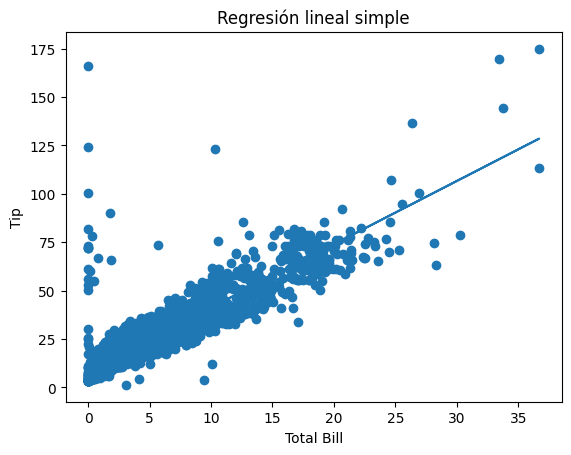

In [69]:
# Visualizar pérdida de la regresión lineal
plt.scatter(x, y)
plt.plot(x, y_pred)
plt.title("Regresión lineal simple")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

### **DESCENSO DE GRADIENTE:**

El **descenso de gradiente** es un algoritmo de optimización ampliamente utilizado en el campo del aprendizaje automático y en la resolución numérica de problemas de optimización.

Su objetivo principal es encontrar el **mínimo de una función**, lo que es esencial en la optimización de modelos y la resolución de problemas matemáticos, para ajustar los parámetros de manera que la **función de costo se minimice**.

El descenso de gradiente tiene la forma:

\begin{equation} (ϴ_0, ϴ_1)_{i+1} = (ϴ_0, ϴ_1)_i - α * \frac{∂\,\,c(ϴ_0, ϴ_1)}{∂(ϴ_0, ϴ_1)} \, \, \,\, \, \,\, \, \, ; \, \, \,\, \, \,\, \, \, α \in (0, 1) \end{equation}

Donde su predicción:

\begin{equation} h_ϴ(x) = ϴ_1x + ϴ_0  \, \, \, \equiv \, \, \, y = mx + b \end{equation}


In [49]:
# Definir parámetros
theta_0 = 0
theta_1 = 0
alpha = 0.0001
epochs = 1000
n = len(x)

cost_history = []

La función de costo tiene la forma:

\begin{equation} c(ϴ_0, ϴ_1) = \frac{1}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)² \end{equation}

Al derivar función de costo:

*   Parámetro 1:

\begin{equation} \frac{∂}{∂(ϴ_0)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i) \end{equation}


*   Paramétro 2:

\begin{equation} \frac{∂}{∂(ϴ_1)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)(x_i) \end{equation}

In [50]:
# Realizar algoritmo del descenso de gradiente
for i in range(epochs):
    y_hat = theta_1 * x + theta_0

    error = y_hat - y

    cost = (1/n) * np.sum(error**2)
    cost_history.append(cost)

    d_theta_0 = (2/n) * np.sum(error)
    d_theta_1 = (2/n) * np.sum(error * x)

    theta_0 -= alpha * d_theta_0
    theta_1 -= alpha * d_theta_1

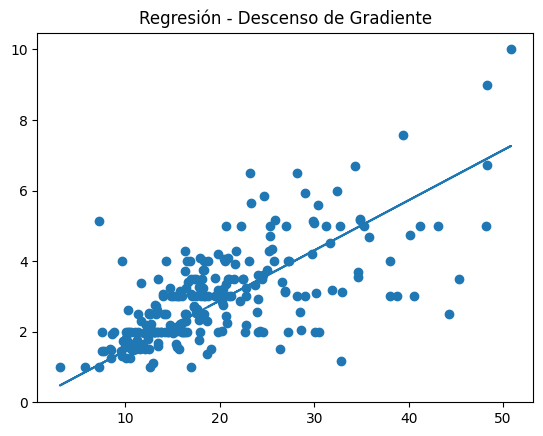

In [51]:
# Visualizar la regresión lineal por descenso de gradiente
y_gd = theta_1 * x + theta_0

plt.scatter(x, y)
plt.plot(x, y_gd)
plt.title("Regresión - Descenso de Gradiente")
plt.show()

In [70]:
# Predicción de valores con descenso de gradiente

x_nuevo = float(input("Ingresa el valor de x: "))

y_pred_nuevo = theta_1 * x_nuevo + theta_0

print("Predicción (y):", y_pred_nuevo)

Ingresa el valor de x: 1
Predicción (y): 9.816072106918782


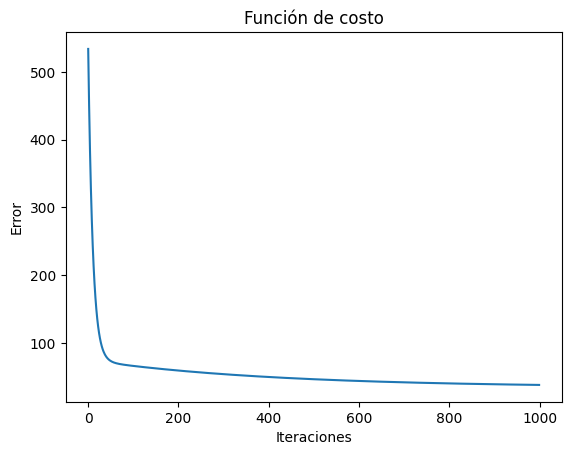

In [71]:
# Visualizar las pérdidas
plt.plot(cost_history)
plt.title("Función de costo")
plt.xlabel("Iteraciones")
plt.ylabel("Error")
plt.show()

In [54]:
# Comparar las rectas obtenidas por los algoritmos


## **CHALLENGE: ANÁLISIS PREDICTIVO DE DATOS**

Una vez visto el ***Hands - On: Introducción a la estadística inferencial***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Dentro de la siguiente dinámica, **se realizará un análisis de estadística inferecial** haciendo uso de **operaciones vectorizadas y visualización de datos** a través del **dataset taxis** proveniente de la librería de ***Seaborn***.

Donde los análisis a realizar son:

*   **Prueba de hipótesis**
*   **Aprendizaje estadístico**

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importa las librerías:** Carga las bibliotecas de Numpy, Pandas, Seaborn y Matplotlib.pyplot.










In [55]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

**2. Importa el dataset de taxis:** Crea una variable denominada df_taxis donde se importe el dataset taxis.

In [56]:
# Importar dataset
df_taxis = sns.load_dataset("taxis")

**3. Realiza una prueba de hipótesis:** Determina si existe una diferencia significativa entre la distancia recorrida de los taxis color amarillo y verde.

Donde:

   * H0: La media de distancia es igual para ambos colores.
   * H1: La media de distancia es distinta entre colores.

In [57]:
# Importar módulo
amarillos = df_taxis[df_taxis['color'] == 'yellow']['distance']
verdes = df_taxis[df_taxis['color'] == 'green']['distance']

In [58]:
# Separación de grupos


print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 0.09222805186888201
p-value: 0.9265931522244976


In [59]:
# Aplicar Prueba T de Student
t_stat, p_value = stats.ttest_ind(amarillos, verdes, nan_policy='omit')

In [60]:
# Interpretación automática
alpha = 0.05

if p_value < alpha:
    print("Rechazamos H0: Existe diferencia significativa en la distancia")
else:
    print("No se puede rechazar H0: No hay evidencia suficiente")

Rechazamos H0: Existe diferencia significativa en la distancia


**4. Realiza un aprendizaje estadístico:**

   * Crea un modelo de regresión lineal simple para predecir el costo del viaje en función de la distancia recorrida.
   * Ajusta el modelo a través del algoritmo de optimización del descenso de gradiente.
   * Utiliza el modelo ajustado para realizar una predicción de cuánto costará un viaje de dado un valor agregado por el usuario en unidades de distancia.

In [61]:
# Definir regresión lineal
x = df_taxis['distance'].values
y = df_taxis['total'].values

In [62]:
# Realizar algoritmo del descenso de gradiente
m = np.cov(x, y)[0,1] / np.var(x)
b = y.mean() - m * x.mean()

y_pred = m * x + b

In [63]:
theta_0 = 0
theta_1 = 0
alpha = 0.001
epochs = 1000
n = len(x)

cost_history = []

for i in range(epochs):
    y_hat = theta_1 * x + theta_0
    error = y_hat - y

    cost = (1/n) * np.sum(error**2)
    cost_history.append(cost)

    d_theta_0 = (2/n) * np.sum(error)
    d_theta_1 = (2/n) * np.sum(error * x)

    theta_0 -= alpha * d_theta_0
    theta_1 -= alpha * d_theta_1


**5. Visualiza los resultados:**

   * Grafica las líneas de las regresiones para comparar entre la regresión lineal simple y el algoritmo de optimización.
   * Grafica la función de costo resultante del ajuste con el algoritmo de optimización.

Costo estimado: 9.816072106918782


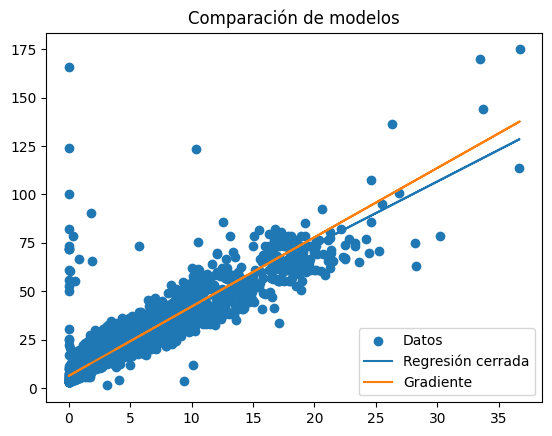

In [64]:
# Visualizar regresiones


print("Costo estimado:", prediccion)
plt.scatter(x, y, label="Datos")

plt.plot(x, y_pred, label="Regresión cerrada")
plt.plot(x, theta_1 * x + theta_0, label="Gradiente")

plt.legend()
plt.title("Comparación de modelos")
plt.show()

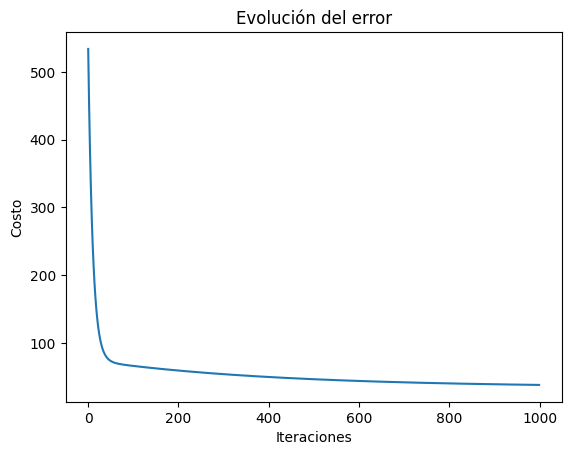

In [65]:
# Visualizar función de costo
plt.plot(cost_history)
plt.title("Evolución del error")
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.show()